## Imports and housekeeping

In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from numpy.ma.core import indices
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from scipy import stats

# Disable these two lines of code during development, they are used to ignore warnings when in "prod".
import warnings
warnings.filterwarnings('ignore')

In [38]:
def corr_plot(input_df):
    corr_df = input_df.corr()
    corr_mat = corr_df[corr_df.columns[::-1]].stack().reset_index(name="correlation")

    sns.set_style("whitegrid")
    g = sns.relplot(
        data=corr_mat,
        x="level_0", y="level_1", hue="correlation", size="correlation",
        palette="vlag", edgecolor=".7",
        height=10, sizes=(50, 250), hue_norm=(-0.5, 1),size_norm=(-0.5, 1),
    )

    g.set(xlabel="", ylabel="", aspect="equal")
    g.despine(left=True, bottom=True)
    g.ax.margins(.02)
    for label in g.ax.get_xticklabels():
        label.set_rotation(90)

In [39]:
data = pd.read_csv('https://raw.githubusercontent.com/LUCE-Blockchain/Databases-for-teaching/refs/heads/main/Framingham%20Dataset.csv')

data

,RANDID,SEX,TOTCHOL,AGE,SYSBP,DIABP,CURSMOKE,CIGPDAY,BMI,DIABETES,...,CVD,HYPERTEN,TIMEAP,TIMEMI,TIMEMIFC,TIMECHD,TIMESTRK,TIMECVD,TIMEDTH,TIMEHYP
0,2448,1,195.0,39,106.0,70.0,0,0.0,26.97,0,...,1,0,8766,6438,6438,6438,8766,6438,8766,8766
1,2448,1,209.0,52,121.0,66.0,0,0.0,NaN,0,...,1,0,8766,6438,6438,6438,8766,6438,8766,8766
2,6238,2,250.0,46,121.0,81.0,0,0.0,28.73,0,...,0,0,8766,8766,8766,8766,8766,8766,8766,8766
3,6238,2,260.0,52,105.0,69.5,0,0.0,29.43,0,...,0,0,8766,8766,8766,8766,8766,8766,8766,8766
4,6238,2,237.0,58,108.0,66.0,0,0.0,28.50,0,...,0,0,8766,8766,8766,8766,8766,8766,8766,8766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11622,9998212,1,173.0,46,126.0,82.0,0,0.0,19.17,0,...,0,1,8766,8766,8766,8766,8766,8766,8766,0
11623,9998212,1,153.0,52,143.0,89.0,0,0.0,25.74,0,...,0,1,8766,8766,8766,8766,8766,8766,8766,0
11624,9999312,2,196.0,39,133.0,86.0,1,30.0,20.91,0,...,0,1,8766,8766,8766,8766,8766,8766,8766,4201
11625,9999312,2,240.0,46,138.0,79.0,1,20.0,26.39,0,...,0,1,8766,8766,8766,8766,8766,8766,8766,4201


## Research questions
-

## Data exploration and cleanup

In [40]:
numeric_df = data.select_dtypes(include=['number'])

In [41]:
data.shape

(11627, 39)

### Statistics

In [42]:
data.describe()

,RANDID,SEX,TOTCHOL,AGE,SYSBP,DIABP,CURSMOKE,CIGPDAY,BMI,DIABETES,...,CVD,HYPERTEN,TIMEAP,TIMEMI,TIMEMIFC,TIMECHD,TIMESTRK,TIMECVD,TIMEDTH,TIMEHYP
count,1.162700e+04,11627.000000,11218.000000,11627.000000,11627.000000,11627.000000,11627.000000,11548.000000,11575.000000,11627.000000,...,11627.000000,11627.000000,11627.000000,11627.000000,11627.000000,11627.000000,11627.000000,11627.000000,11627.000000,11627.000000
mean,5.004741e+06,1.568074,241.162418,54.792810,136.324116,83.037757,0.432528,8.250346,25.877349,0.045584,...,0.249333,0.743270,7241.556893,7593.846736,7543.036725,7008.153608,7660.880021,7166.082996,7854.102950,3598.956395
std,2.900877e+06,0.495366,45.368030,9.564299,22.798625,11.660144,0.495448,12.186888,4.102640,0.208589,...,0.432646,0.436848,2477.780010,2136.730285,2192.120311,2641.344513,2011.077091,2541.668477,1788.369623,3464.164659
min,2.448000e+03,1.000000,107.000000,32.000000,83.500000,30.000000,0.000000,0.000000,14.430000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.000000,0.000000
25%,2.474378e+06,1.000000,210.000000,48.000000,120.000000,75.000000,0.000000,0.000000,23.095000,0.000000,...,0.000000,0.000000,6224.000000,7212.000000,7049.500000,5598.500000,7295.000000,6004.000000,7797.500000,0.000000
50%,5.006008e+06,2.000000,238.000000,54.000000,132.000000,82.000000,0.000000,0.000000,25.480000,0.000000,...,0.000000,1.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,2429.000000
75%,7.472730e+06,2.000000,268.000000,62.000000,149.000000,90.000000,1.000000,20.000000,28.070000,0.000000,...,0.000000,1.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,7329.000000
max,9.999312e+06,2.000000,696.000000,81.000000,295.000000,150.000000,1.000000,90.000000,56.800000,1.000000,...,1.000000,1.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000


### Graphs

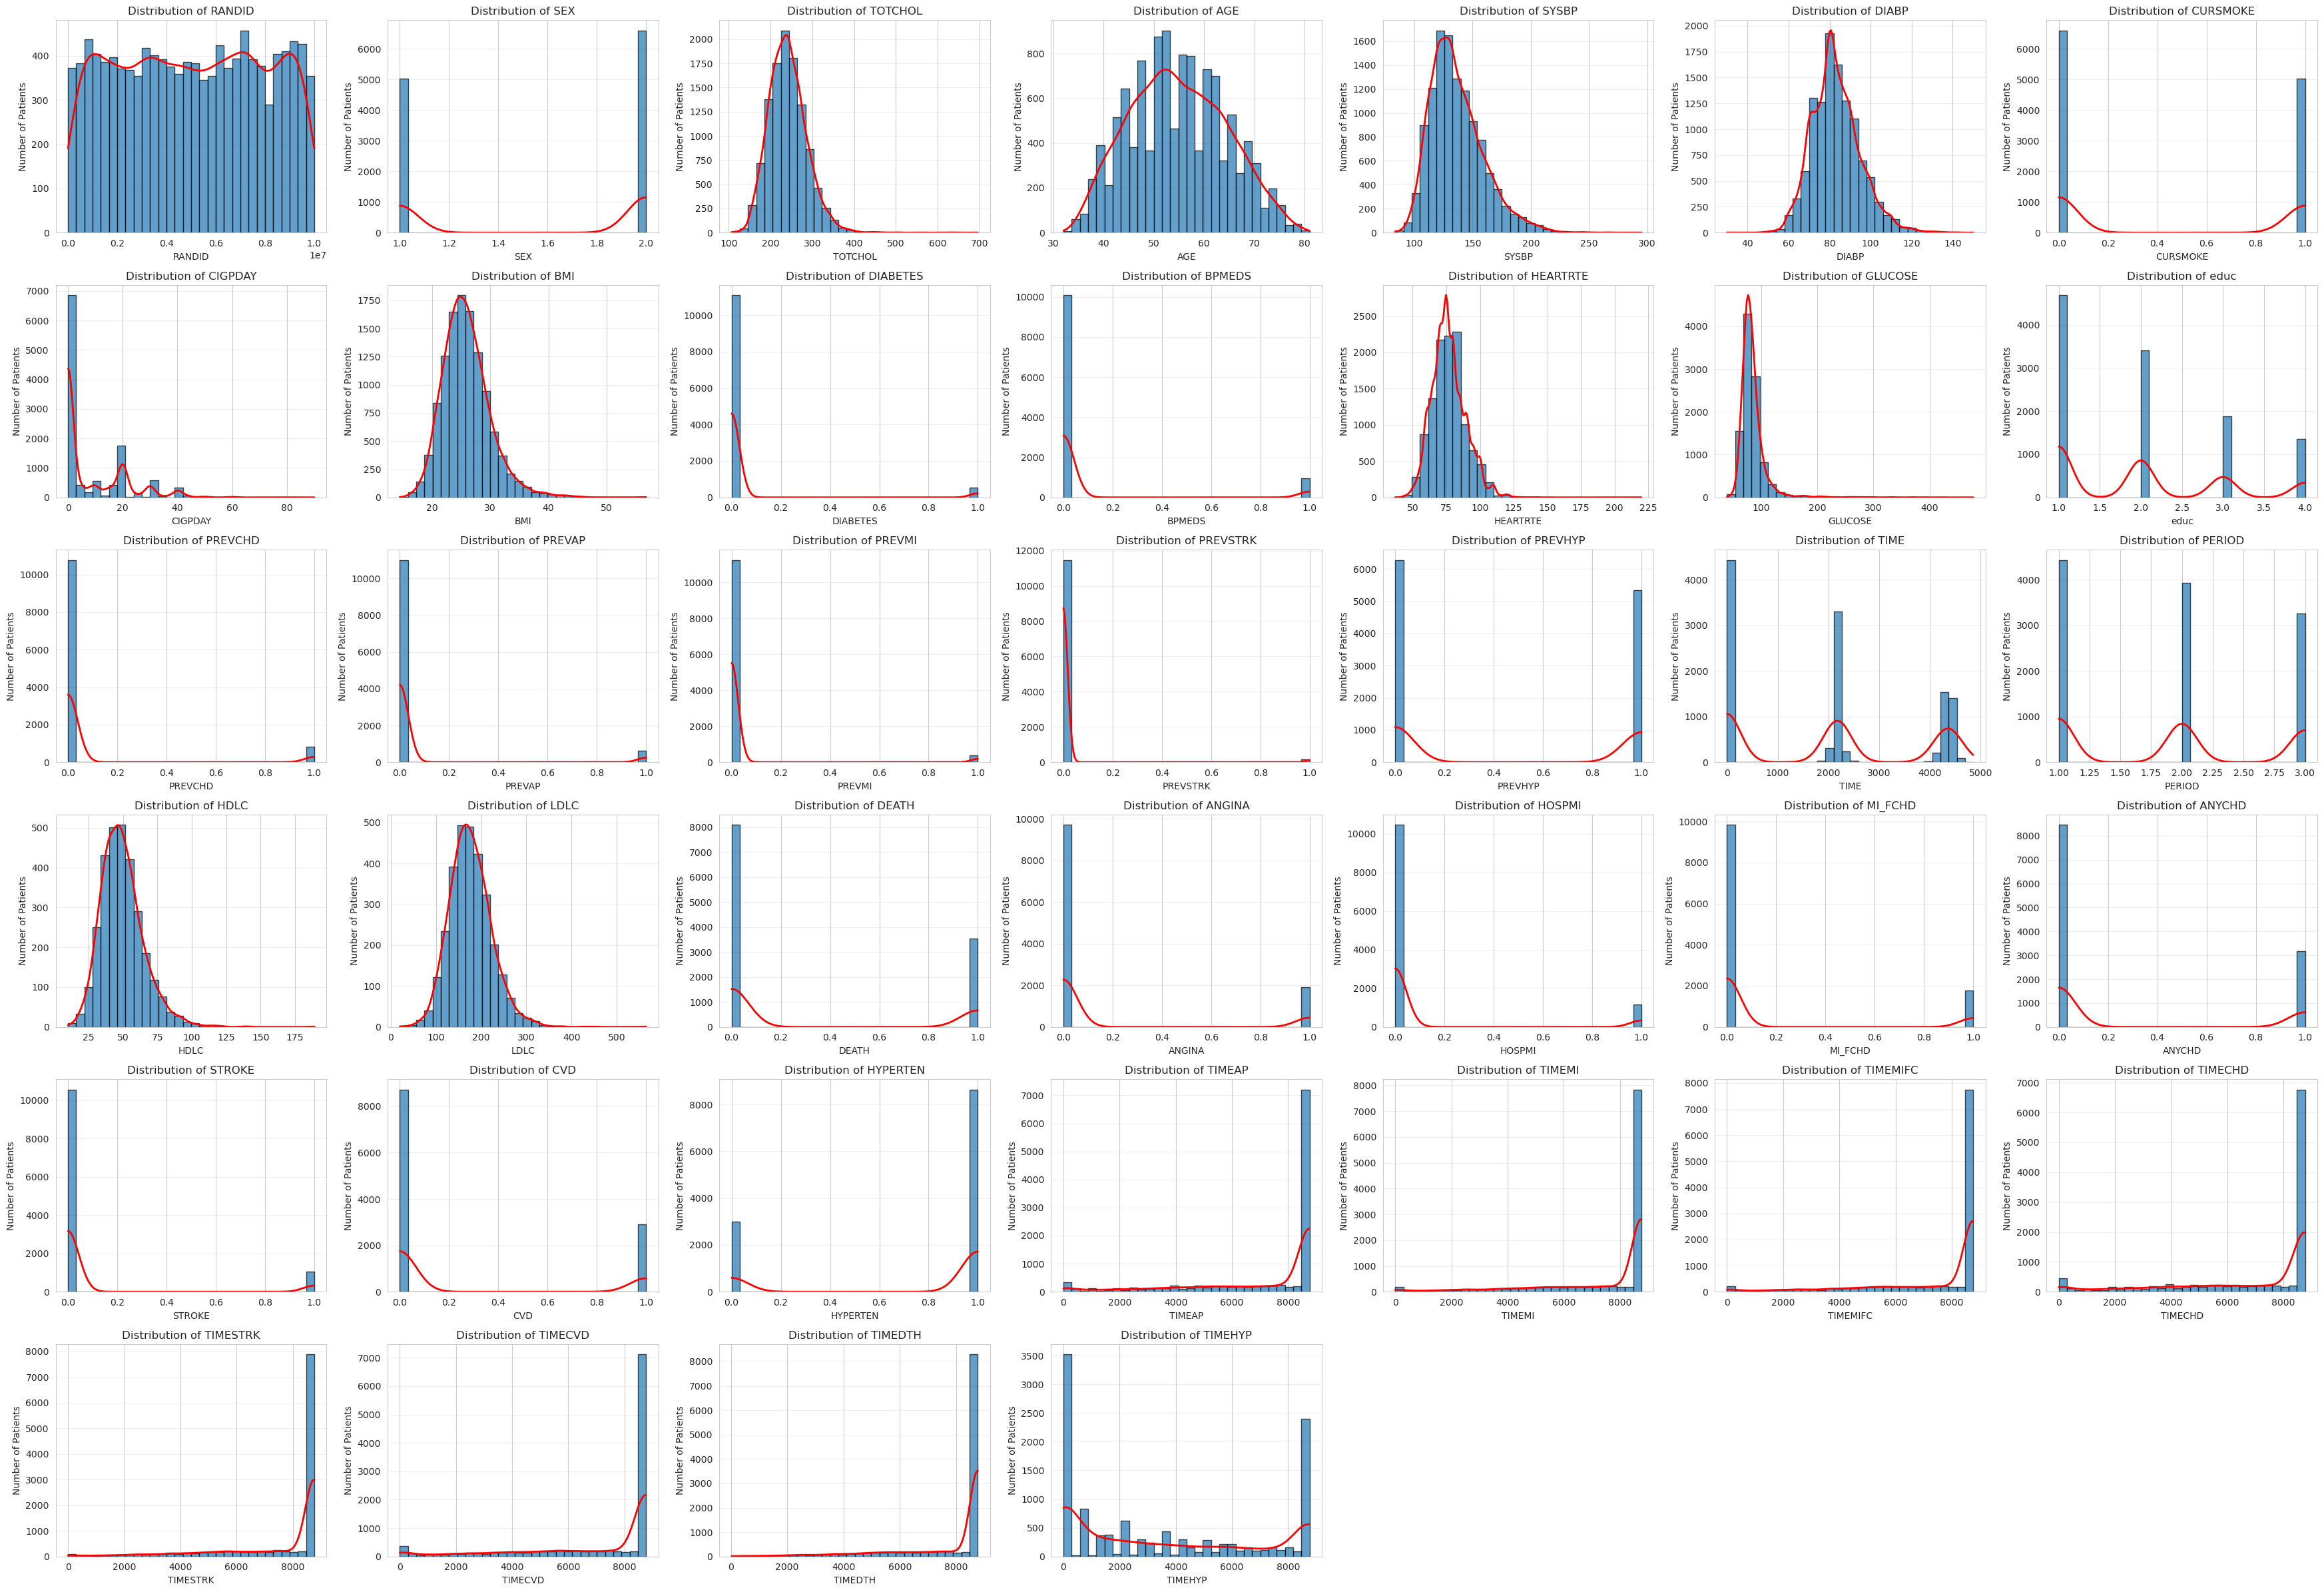

In [43]:
num_features = len(numeric_df.columns)
cols = int(np.ceil(np.sqrt(num_features)))
rows = int(np.ceil(num_features / cols))

# A figure with subplots looks much nicer
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, column in enumerate(numeric_df.columns):
    # Technically not needed but might as well
    numeric_df_nona = numeric_df[column].dropna()

    axes[i].hist(numeric_df_nona, bins=30, alpha=0.7, edgecolor='black')

    if len(numeric_df_nona) > 1:
        density = stats.gaussian_kde(numeric_df_nona)
        xs = np.linspace(numeric_df_nona.min(), numeric_df_nona.max(), 200)
        axes[i].plot(xs, density(xs) * len(numeric_df_nona) * (numeric_df_nona.max() - numeric_df_nona.min()) / 30, 'r-', linewidth=2)

    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Number of Patients')
    axes[i].set_title(f'Distribution of {column}')
    axes[i].grid(axis='y', alpha=0.3)

# Remove any empty subplots if they exist
for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

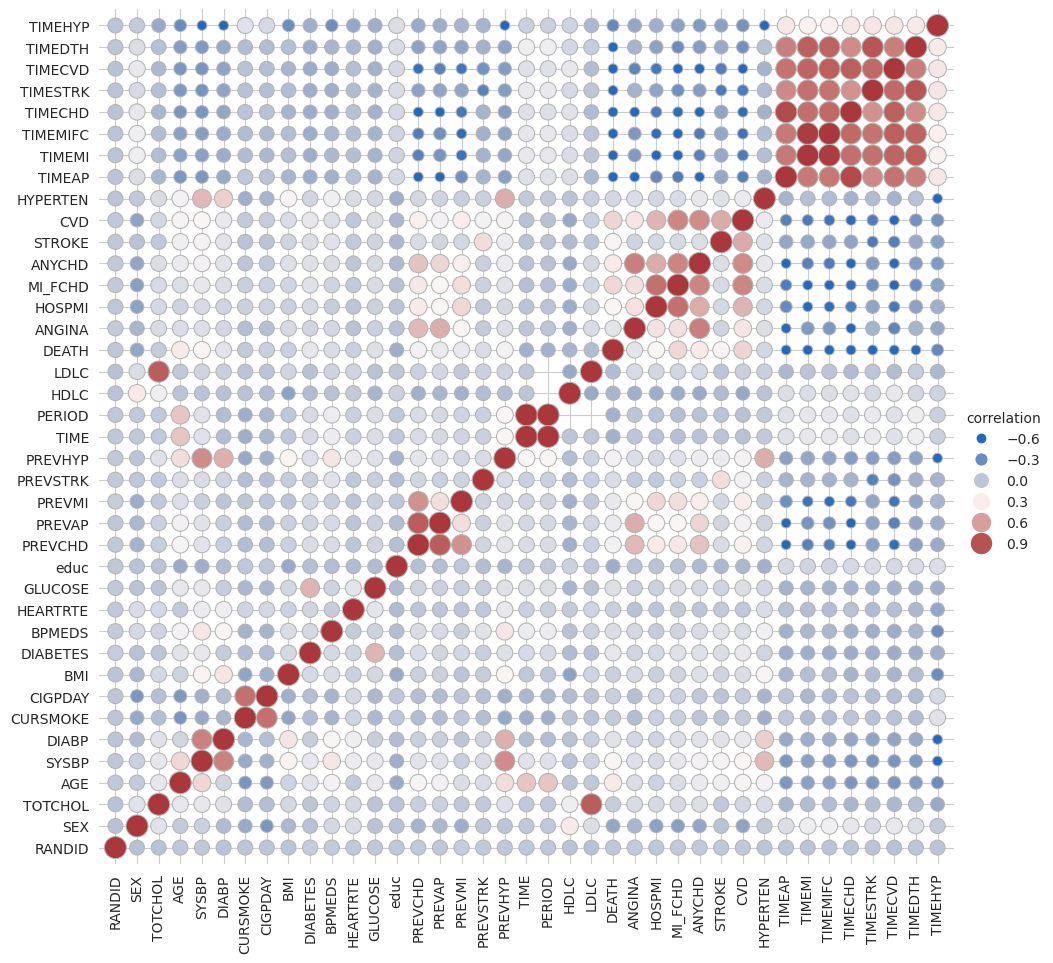

In [44]:
corr_plot(data)

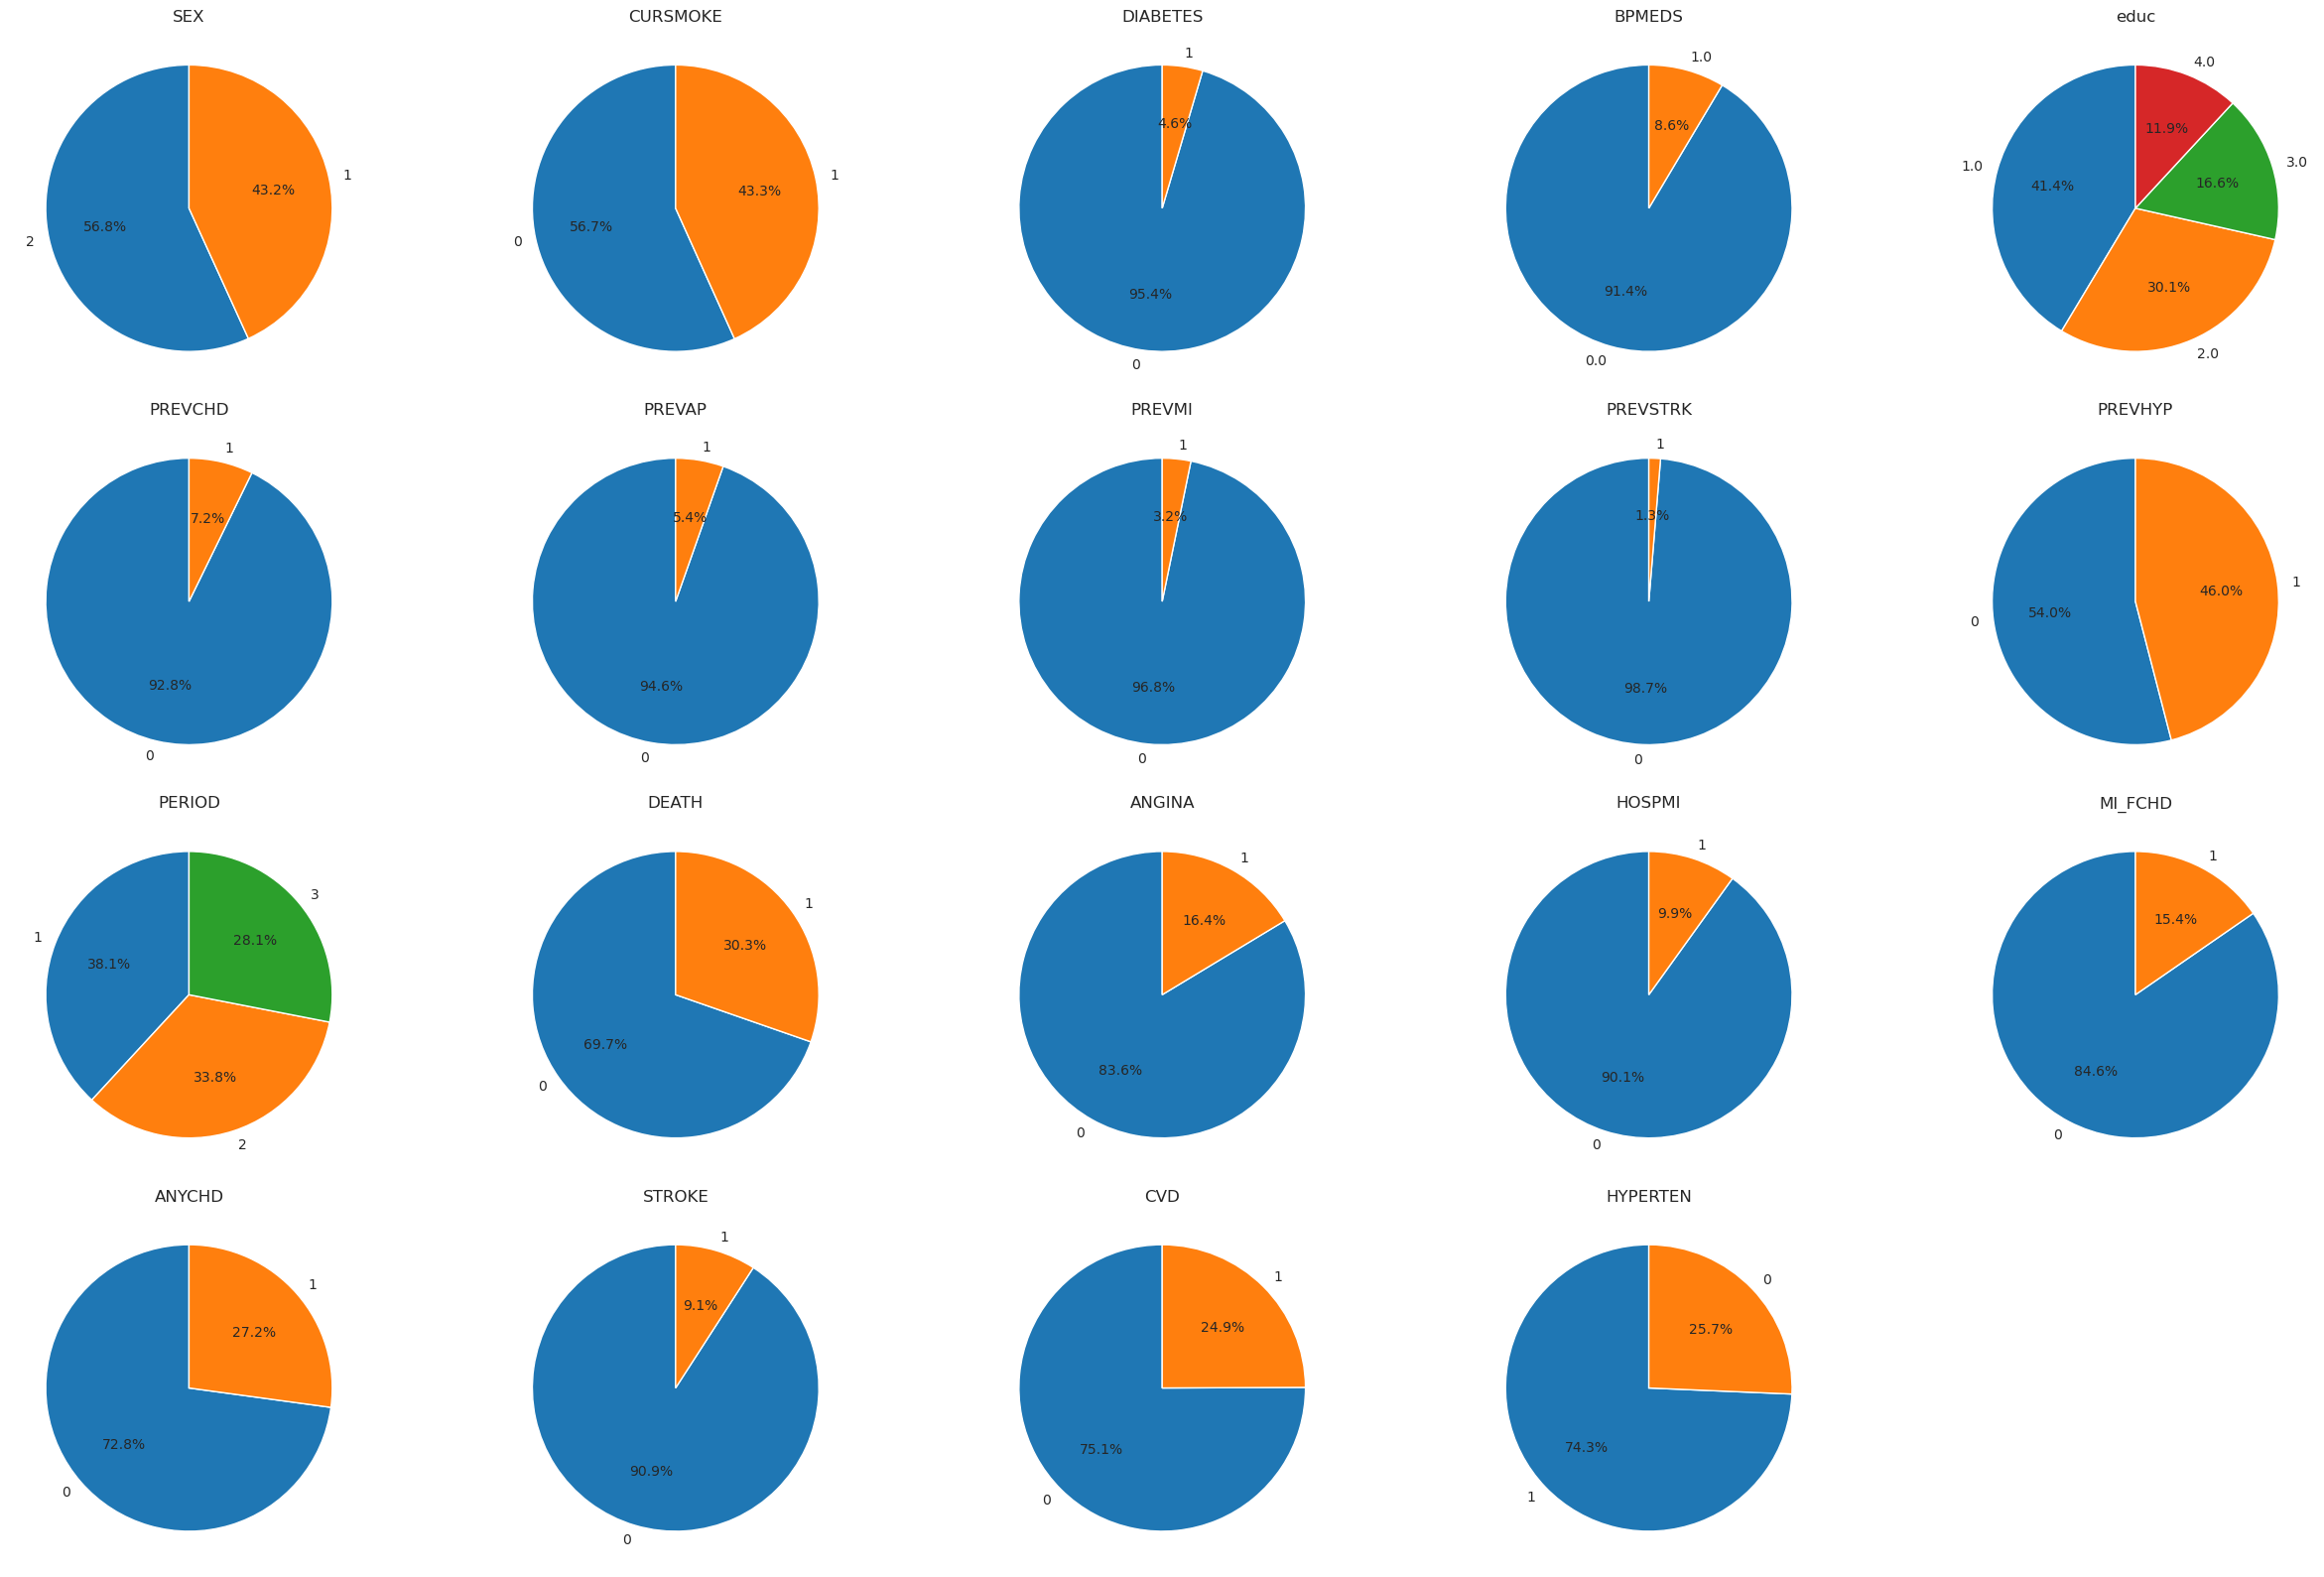

In [45]:
binary_cols = [col for col in data.columns if
               data[col].dropna().isin([0, 1, 2, 3, 4]).all() and len(data[col].dropna().unique()) <= 4]

num_binary = len(binary_cols)
cols = int(np.ceil(np.sqrt(num_binary)))
rows = int(np.ceil(num_binary / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten() if num_binary > 1 else [axes]

for i, col in enumerate(binary_cols):
    value_counts = data[col].value_counts()
    axes[i].pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'{col}')

for j in range(num_binary, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


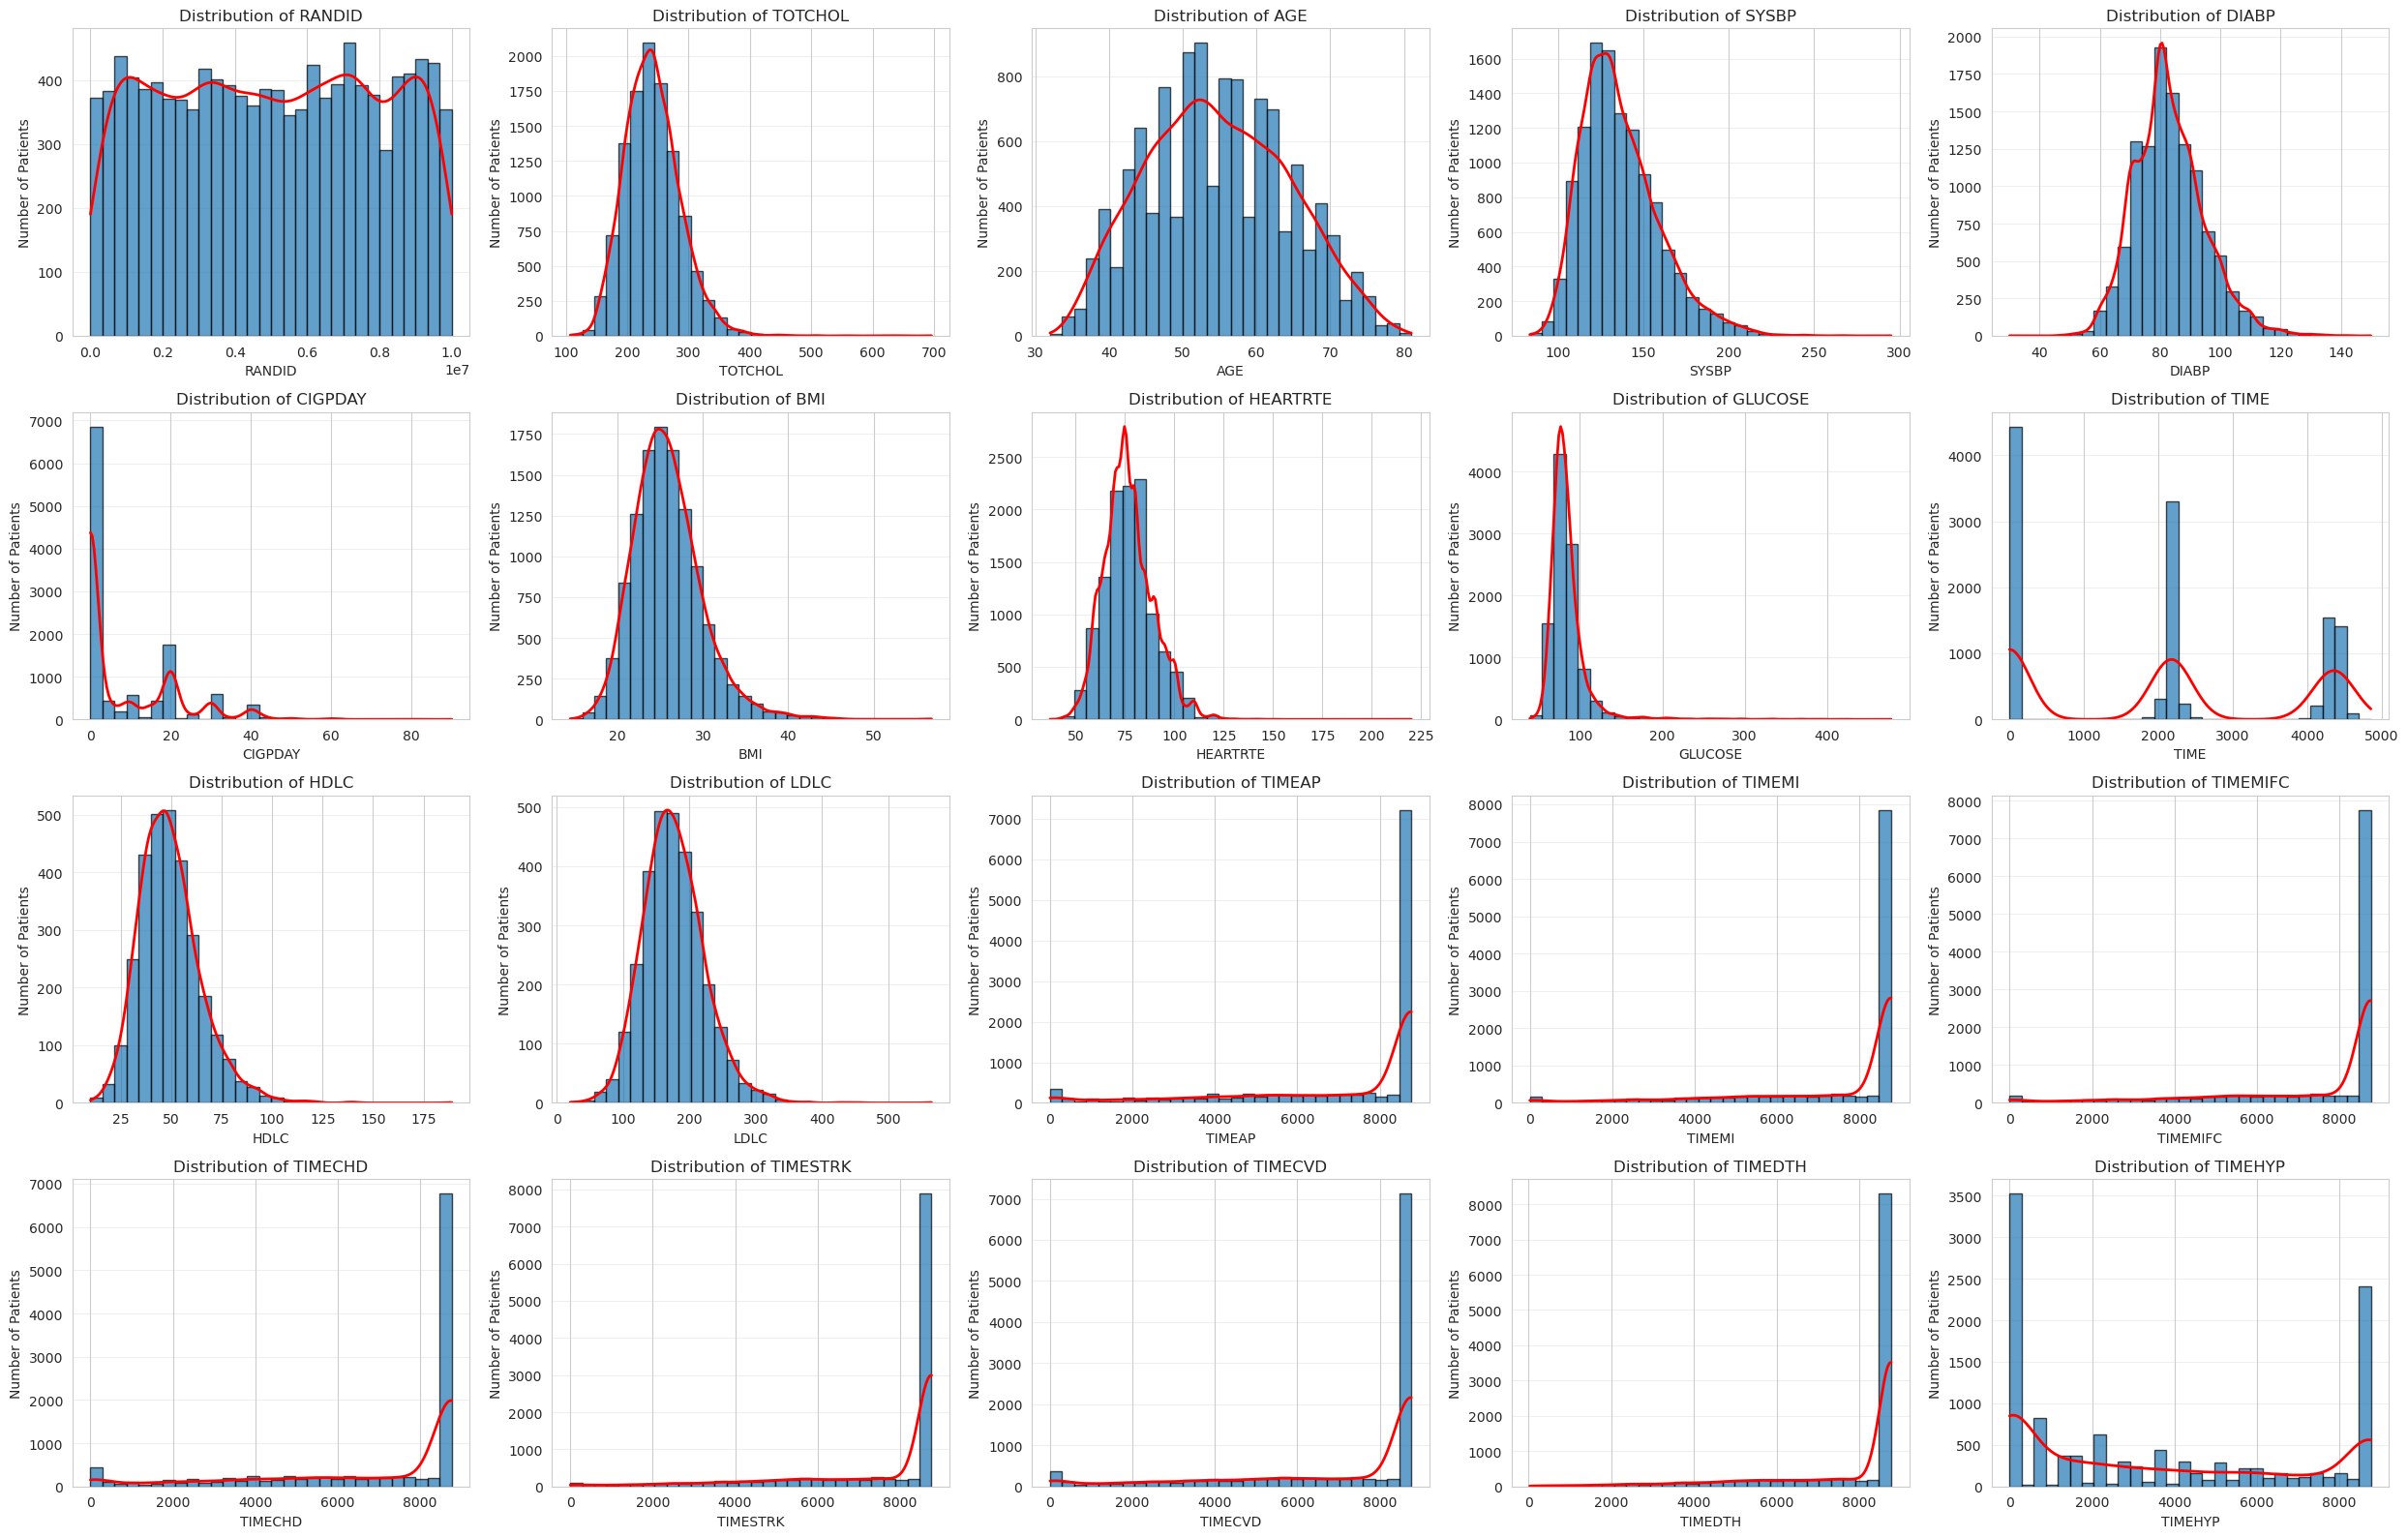

In [46]:
numeric_df_nobin = numeric_df.drop(binary_cols, axis=1)

num_features_no_bin = len(numeric_df_nobin.columns)
cols = int(np.ceil(np.sqrt(num_features_no_bin)))
rows = int(np.ceil(num_features_no_bin / cols))

# A figure with subplots looks much nicer
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, column in enumerate(numeric_df_nobin.columns):
    # Technically not needed but might as well
    numeric_df_nobin_nona = numeric_df_nobin[column].dropna()

    axes[i].hist(numeric_df_nobin_nona, bins=30, alpha=0.7, edgecolor='black')

    if len(numeric_df_nobin_nona) > 1:
        density = stats.gaussian_kde(numeric_df_nobin_nona)
        xs = np.linspace(numeric_df_nobin_nona.min(), numeric_df_nobin_nona.max(), 200)
        axes[i].plot(xs, density(xs) * len(numeric_df_nobin_nona) * (numeric_df_nobin_nona.max() - numeric_df_nobin_nona.min()) / 30, 'r-', linewidth=2)

    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Number of Patients')
    axes[i].set_title(f'Distribution of {column}')
    axes[i].grid(axis='y', alpha=0.3)

# Remove any empty subplots if they exist
for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Detecting outliers in the numerical columns

In [47]:
numerical_cols = data.select_dtypes(include=np.number).columns
outlier_indices = {}

for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    indices = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index
    if len(indices) > 0:
            outlier_indices[col] = indices.tolist()
            #print(f'{len(indices)} outliers found in {col} column')
    else:
        pass
        #print(f"No outlier data found for column {col}")

outlier_values = []
outliers_count = 0
for col, rows in outlier_indices.items():
    outlier_values.append([col, len(rows), (len(rows) / len(data[col]))])
    outliers_count = outliers_count + 1 if len(rows) > 0 else outliers_count

if outliers_count > 0:
    data_outliers = pd.DataFrame(outlier_values)
    data_outliers.columns = ['Variable', 'Outliers', 'Percentage Outliers']
    s = data_outliers.sort_values(by=['Percentage Outliers'], ascending=False).style.bar(subset=['Percentage Outliers'], color='#d65f5f')
    display(s)
else:
    print('No outlier values found in the dataset.')




,Variable,Outliers,Percentage Outliers
19,CVD,2899,0.249333
26,TIMEDTH,1933,0.166251
15,ANGINA,1902,0.163585
17,MI_FCHD,1788,0.153780
24,TIMESTRK,1489,0.128064
21,TIMEMI,1484,0.127634
22,TIMEMIFC,1347,0.115851
16,HOSPMI,1154,0.099252
18,STROKE,1061,0.091253
6,BPMEDS,944,0.081190


### Data imputation

In [48]:
missing  = 0
misVariables = []
CheckNull = data.isnull().sum()
for var in range(0, len(CheckNull)):
    misVariables.append([data.columns[var], CheckNull[var], round(CheckNull[var]/len(data),3)])
    missing = missing + 1

if missing == 0:
    print('Dataset is complete with no blanks.')
else:
    data_misVariables = pd.DataFrame.from_records(misVariables)
    data_misVariables.columns = ['Variable', 'Missing', 'Percentage missing']
    s = data_misVariables.sort_values(by=['Percentage missing'], ascending=False).style.bar(subset=['Percentage missing'], color='#d65f5f')
    display(s)



,Variable,Missing,Percentage missing
22,LDLC,8601,0.740000
21,HDLC,8600,0.740000
12,GLUCOSE,1440,0.124000
10,BPMEDS,593,0.051000
2,TOTCHOL,409,0.035000
13,educ,295,0.025000
7,CIGPDAY,79,0.007000
8,BMI,52,0.004000
11,HEARTRTE,6,0.001000
6,CURSMOKE,0,0.000000


Dropping columns with more than 50% missing data

In [49]:
from imputation_functions import drop_high_missing_cols
data_dropped = drop_high_missing_cols(data, threshold=0.50)

--- Running Step 1: Dropping columns > 50% missing ---
   -> Dropping columns: HDLC, LDLC


Using KNN Classifier or Regressor (based on data category) on columns between 2% and 50%

In [50]:
from imputation_functions import knn_impute
data_knn_predicted= knn_impute(data_dropped, min_thresh=0.02, max_thresh=0.50, n_neighbors=5)



--- Running Step 2: KNN Imputation (2% - 50% missing) ---
   -> No categorical columns found. Skipping encoding.
   -> KNN Imputing 'TOTCHOL' (Missing: 3.52%)
      -> Successfully imputed 409 values.
   -> KNN Imputing 'BPMEDS' (Missing: 5.10%)
      -> Successfully imputed 593 values.
   -> KNN Imputing 'GLUCOSE' (Missing: 12.38%)
      -> Successfully imputed 1440 values.
   -> KNN Imputing 'educ' (Missing: 2.54%)
      -> Successfully imputed 295 values.
   -> Skipping reconstruction (no categorical columns).


Using measures of central tendency on columns where <2% of data is missing

In [51]:
# The imputation function is defined in imputation_functions.py, but we should import it back into the Jupyter notebook in order to make it easier for the professors to correct.
from imputation_functions import impute_simple_central

data_imputed = impute_simple_central(data_knn_predicted)



--- Running Step 3: Simple Imputation (< 5% missing) ---
   -> Found 'CIGPDAY' with 0.68% missing values. Imputing...
      -> Filled with median: 0.0
   -> Found 'BMI' with 0.45% missing values. Imputing...
      -> Filled with median: 25.48
   -> Found 'HEARTRTE' with 0.05% missing values. Imputing...
      -> Filled with median: 75.0
   -> Simple imputation complete.


Code for showing if the imputation successful was

In [52]:
missing  = 0
misVariables = []
CheckNull = data_imputed.isnull().sum()
for var in range(0, len(CheckNull)):
    misVariables.append([data_imputed.columns[var], CheckNull[var], round(CheckNull[var]/len(data),3)])
    missing = missing + 1

if missing == 0:
    print('Dataset is complete with no blanks.')
else:
    data_misVariables = pd.DataFrame.from_records(misVariables)
    data_misVariables.columns = ['Variable', 'Missing', 'Percentage missing']
    s = data_misVariables.sort_values(by=['Percentage missing'], ascending=False).style.bar(subset=['Percentage missing'], color='#d65f5f')
    display(s)

,Variable,Missing,Percentage missing
0,RANDID,0,0.000000
1,SEX,0,0.000000
2,TOTCHOL,0,0.000000
3,AGE,0,0.000000
4,SYSBP,0,0.000000
5,DIABP,0,0.000000
6,CURSMOKE,0,0.000000
7,CIGPDAY,0,0.000000
8,BMI,0,0.000000
9,DIABETES,0,0.000000


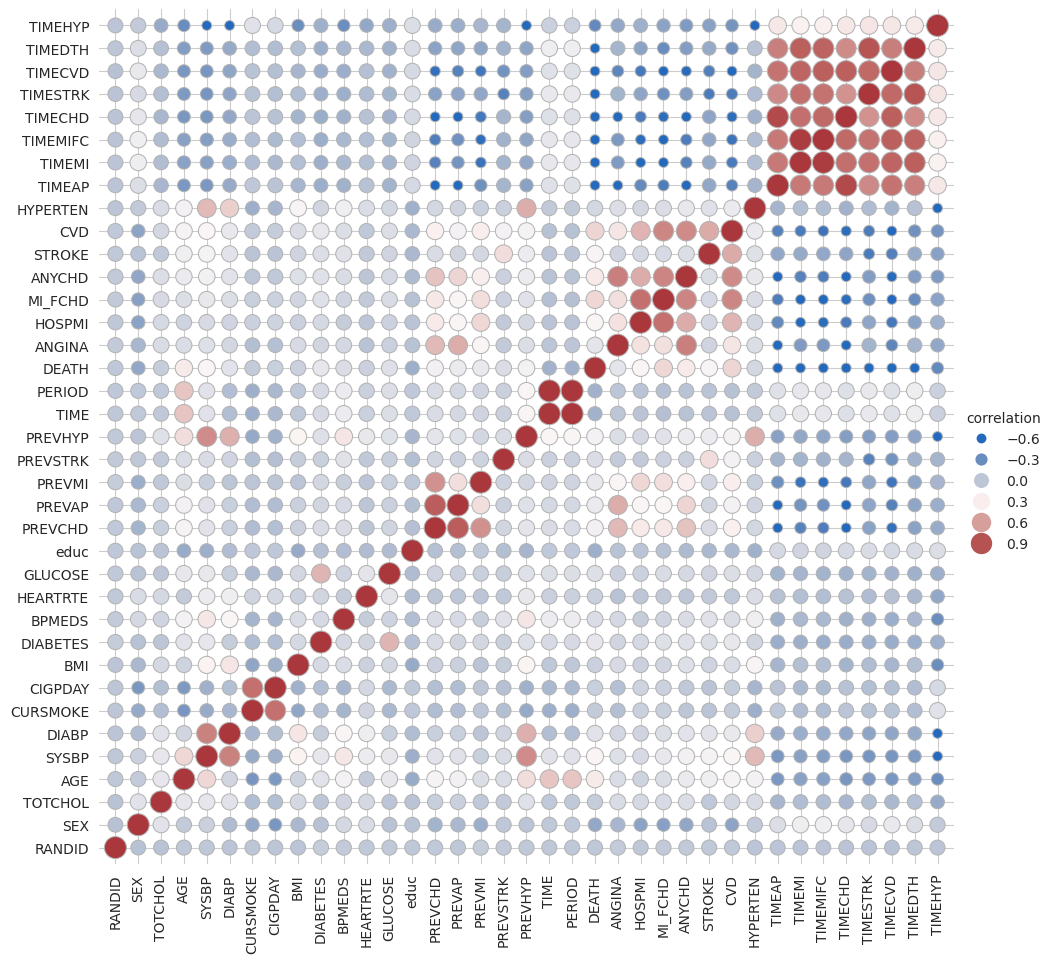

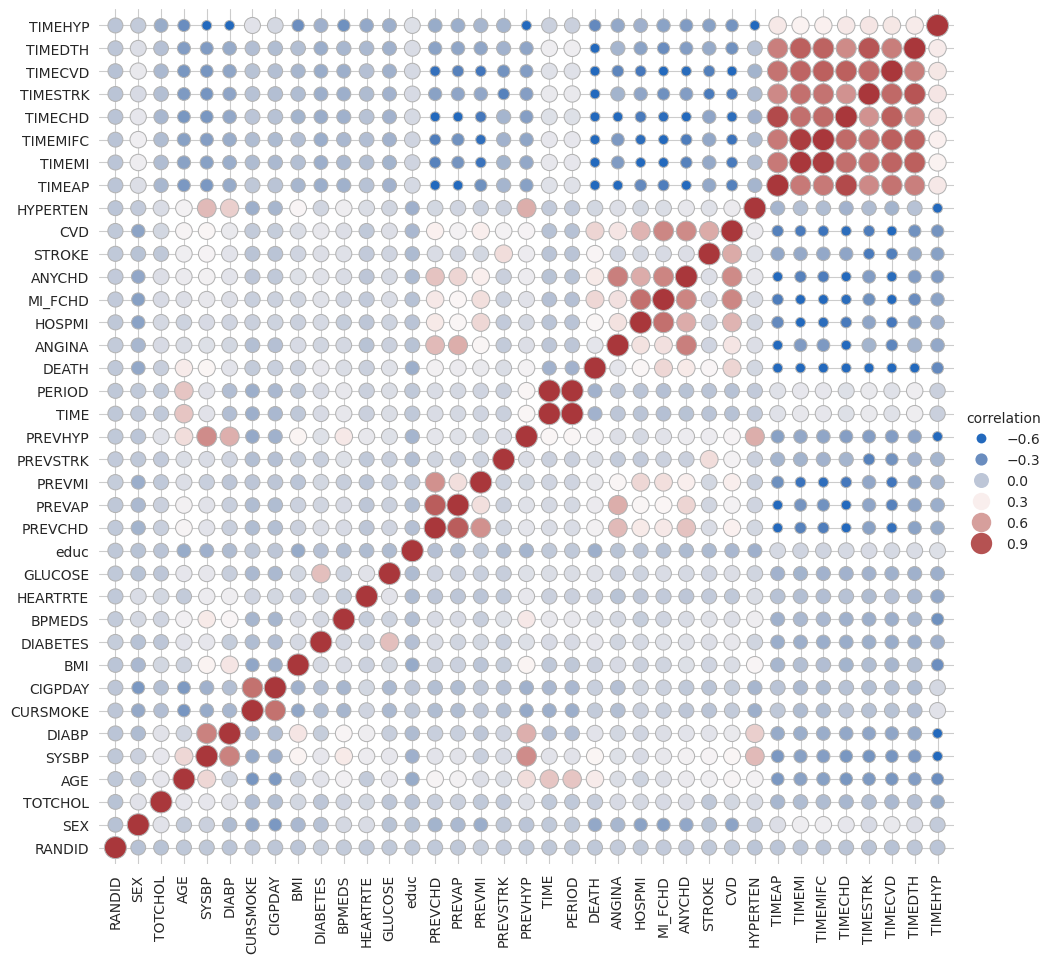

In [53]:
corr_plot(data.drop(columns=['HDLC','LDLC']))
corr_plot(data_imputed)

ValueError: '5D3A9B' is not a valid color value.

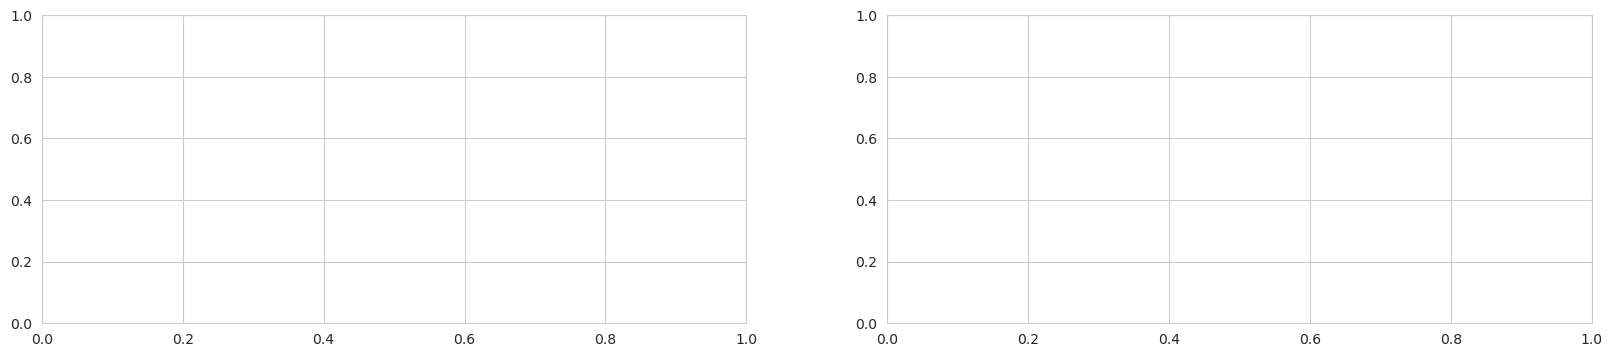

In [54]:
for column in data_imputed:
    defined_variable = column
    original = data[defined_variable]
    imputed = data_imputed[defined_variable]

    fig, axes = plt.subplots(1, 2, figsize=(20, 4))

    axes[0].hist(original.dropna(), bins=30, alpha=0.7, color='5D3A9B', edgecolor='black')
    if len(original.dropna()) > 1:
        from scipy import stats

        density = stats.gaussian_kde(original.dropna())
        xs = np.linspace(original.min(), original.max(), 200)
        axes[0].plot(xs, density(xs) * len(original.dropna()) * (original.max() - original.min()) / 30, 'r-',
                     linewidth=2)
    axes[0].set_xlabel(defined_variable)
    axes[0].set_ylabel('Density')
    axes[0].set_title('Original')
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].hist(imputed, bins=30, alpha=0.7, color='E66100', edgecolor='black')
    if len(imputed) > 1:
        density = stats.gaussian_kde(imputed)
        xs = np.linspace(imputed.min(), imputed.max(), 200)
        axes[1].plot(xs, density(xs) * len(imputed) * (imputed.max() - imputed.min()) / 30, 'r-', linewidth=2)
    axes[1].set_xlabel(defined_variable)
    axes[1].set_ylabel('Density')
    axes[1].set_title('Simple Imputed')
    axes[1].grid(axis='y', alpha=0.3)

    plt.suptitle(f'Distribution Comparison of {defined_variable}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


## Data skewness

In [ ]:
# TODO: fix data skewness. Left skewed: use exponential transformation Right skewed: use logarithmic transformation. Use scipy.stats.skew to identify skewness.